**Autores:**

- Gonçalo Henriques (123422)
- Rodrigo Sousa (123390)

In [38]:
import os
os.chdir('/home/jovyan/work')

# Instalar dependências em falta no ambiente Docker
import subprocess
subprocess.run(['pip', 'install', '-q', 'folium'], check=True)

# Importações básicas
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml import Pipeline
from pymongo import MongoClient
import pandas as pd
import matplotlib.pyplot as plt
import folium
import pprint

In [39]:
# Criar SparkSession
spark = (
    SparkSession.builder
        .appName('LondonBikesModelling')
        .master('local[4]')
        .config('spark.driver.memory', '4g')
        .getOrCreate()
)
spark

In [40]:
# Ligar ao MongoDB
client = MongoClient('mongodb://mongodb:27017/')
db = client['london_bikes']
client.admin.command('ping')
client

MongoClient(host=['mongodb:27017'], document_class=dict, tz_aware=False, connect=True)

---
# **4 - Modelação: Clustering de Utilizações**

Este notebook aplica o algoritmo **K-Means** para classificar cada observação de disponibilidade de bicicletas num de três estados de utilização, durante o período de Verão (Junho–Setembro 2022).

**Abordagem:** O clustering é realizado ao **nível da observação** — cada registo (instante de tempo × estação) é classificado individualmente, resultando em ~3 milhões de observações classificadas. Esta abordagem permite acompanhar a evolução do estado de cada estação ao longo do tempo.

**Features usadas:**
- `bikes` — número de bicicletas disponíveis no momento
- `docks` — capacidade total da estação (número de docas)
- `empty_docks` — número de docas vazias no momento

**Justificação de K=3:**
O número de clusters é definido pelo **problema**, não pelos dados. Uma estação de bicicletas pode estar em um de três estados:
1. **Excessivo** — muita procura: poucas bicicletas, muitas docas vazias
2. **Moderado** — muitas bicicletas disponíveis, poucas docas ocupadas
3. **Frequente** — estado de equilíbrio: valores intermédios de bikes e empty_docks

**Pipeline:**
1. Carregar `bikes_clean_summer` do MongoDB
2. Construir pipeline: VectorAssembler → StandardScaler → KMeans (K=3)
3. Avaliar com coeficiente de Silhouette
4. Atribuir nomes aos clusters com base nos centróides
5. Guardar resultados em `bikes_modelled_summer` no MongoDB
6. Visualização geográfica com Folium (janela temporal filtrada)

**NOTA:** Este notebook deve ser executado após `2-DataUnderstanding.ipynb` e `3-StationsCleaning.ipynb`.

---
## **1. Carregar Dados**

In [41]:
# Ler a collection bikes_clean_summer do MongoDB via Spark
df_summer_base = (
    spark.read
        .format('mongodb')
        .option('connection.uri', 'mongodb://mongodb:27017/')
        .option('database', 'london_bikes')
        .option('collection', 'bikes_clean_summer')
        .load()
)

# Ler a dimensão de estações limpa para obter o nome legível de cada BikePoint
df_stations = (
    spark.read
        .format('mongodb')
        .option('connection.uri', 'mongodb://mongodb:27017/')
        .option('database', 'london_bikes')
        .option('collection', 'stations_clean')
        .load()
        .select('place_id', 'common_name')
)

# Juntar as duas bases de dados pelo identificador natural da estação
df_summer = df_summer_base.join(df_stations, on='place_id', how='left')

print(f'Total de registos (Verão): {df_summer.count():,}')
df_summer.printSchema()
df_summer.select('place_id', 'common_name', 'query_time', 'Date', 'Hour', 'Minute', 'lat', 'lon', 'bikes', 'empty_docks', 'docks').show(5, truncate=False)

Total de registos (Verão): 3,048,965
root
 |-- place_id: string (nullable = true)
 |-- Date: timestamp (nullable = true)
 |-- Hour: integer (nullable = true)
 |-- Minute: integer (nullable = true)
 |-- _id: string (nullable = true)
 |-- bikes: integer (nullable = true)
 |-- docks: integer (nullable = true)
 |-- empty_docks: integer (nullable = true)
 |-- lat: double (nullable = true)
 |-- lon: double (nullable = true)
 |-- query_time: timestamp (nullable = true)
 |-- common_name: string (nullable = true)

+-------------+---------------------------+-----------------------+-------------------+----+------+---------+---------+-----+-----------+-----+
|place_id     |common_name                |query_time             |Date               |Hour|Minute|lat      |lon      |bikes|empty_docks|docks|
+-------------+---------------------------+-----------------------+-------------------+----+------+---------+---------+-----+-----------+-----+
|BikePoints_85|Tanner Street, Bermondsey  |2022-07-02 00:

---
## **2. Preparação de Features**

As features usadas são os valores brutos de `bikes`, `docks` e `empty_docks` em cada observação. Não é feita nenhuma agregação — cada linha do dataset representa um ponto de dados independente para o clustering.

In [42]:
# Estatísticas descritivas das features de clustering
df_summer.select('bikes', 'docks', 'empty_docks').describe().show()

+-------+-----------------+------------------+------------------+
|summary|            bikes|             docks|       empty_docks|
+-------+-----------------+------------------+------------------+
|  count|          3048965|           3048965|           3048965|
|   mean|10.13131866059466|25.633604518254554|15.502285857659894|
| stddev|8.722106146749818| 8.304687820875422| 9.777991251009263|
|    min|                0|                 1|                 0|
|    max|               63|                64|                64|
+-------+-----------------+------------------+------------------+



In [43]:
# Colunas de features para o clustering
feature_cols = ['bikes', 'docks', 'empty_docks']

# Vetorizar as features
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol='features_raw'
)

# Normalizar (média=0, desvio=1) para que nenhuma feature domine pela escala
scaler = StandardScaler(
    inputCol='features_raw',
    outputCol='features',
    withStd=True,
    withMean=False
)

print('Assembler e Scaler configurados.')
print(f'Features: {feature_cols}')

Assembler e Scaler configurados.
Features: ['bikes', 'docks', 'empty_docks']


---
## **3. Justificação de K=3**

O número de clusters K=3 é motivado pelo **domínio do problema**: uma estação de bicicletas partilhadas pode estar em três estados operacionais distintos — utilização excessiva (sem bicicletas disponíveis), utilização moderada (muitas bicicletas disponíveis) e utilização frequente (estado de equilíbrio).

Para confirmar que K=3 é uma escolha razoável do ponto de vista dos dados, compara-se o coeficiente de Silhouette para K ∈ {2, 3, 4}.

In [44]:
# Pré-processar uma amostra para a comparação de K (evitar timeout nos 3M de linhas)
df_sample = df_summer.sample(fraction=0.05, seed=42).cache()
print(f'Tamanho da amostra: {df_sample.count():,} observações')

assembler_tmp = VectorAssembler(inputCols=feature_cols, outputCol='features_raw')
scaler_tmp = StandardScaler(inputCol='features_raw', outputCol='features', withStd=True, withMean=False)

df_tmp = assembler_tmp.transform(df_sample)
scaler_model_tmp = scaler_tmp.fit(df_tmp)
df_tmp_scaled = scaler_model_tmp.transform(df_tmp).cache()

evaluator_k = ClusteringEvaluator(
    featuresCol='features',
    metricName='silhouette',
    distanceMeasure='squaredEuclidean'
)

print('\nComparação de K (amostra 5%):')
print(f'{"K":>4}  {"Silhouette":>12}')
for k in [2, 3, 4]:
    km_tmp = KMeans(featuresCol='features', k=k, seed=42)
    model_tmp = km_tmp.fit(df_tmp_scaled)
    preds_tmp = model_tmp.transform(df_tmp_scaled)
    sil = evaluator_k.evaluate(preds_tmp)
    print(f'{k:>4}  {sil:>12.4f}')

df_tmp_scaled.unpersist()
df_sample.unpersist()

Tamanho da amostra: 152,438 observações

Comparação de K (amostra 5%):
   K    Silhouette
   2        0.5229
   3        0.5604
   4        0.5328


DataFrame[place_id: string, Date: timestamp, Hour: int, Minute: int, _id: string, bikes: int, docks: int, empty_docks: int, lat: double, lon: double, query_time: timestamp, common_name: string]

---
## **4. Treino do Modelo Final**

O pipeline completo é treinado sobre todo o dataset de Verão (sem amostragem), com K=3.

In [45]:
# Construir o pipeline: vetorização → normalização → K-Means (K=3)
kmeans = KMeans(
    featuresCol='features',
    k=3,
    seed=42,
    distanceMeasure='euclidean'
)

pipeline = Pipeline(stages=[assembler, scaler, kmeans])

# Treinar o modelo sobre todo o dataset de Verão
print('A treinar o modelo K-Means (K=3) sobre o dataset completo...')
modelo = pipeline.fit(df_summer)
print('Modelo treinado.')

A treinar o modelo K-Means (K=3) sobre o dataset completo...
Modelo treinado.


In [46]:
# Aplicar o modelo: atribuir um cluster a cada observação
df_pred = modelo.transform(df_summer)

print('Distribuição de observações por cluster:')
df_pred.groupBy('prediction').count().orderBy('prediction').show()

Distribuição de observações por cluster:
+----------+-------+
|prediction|  count|
+----------+-------+
|         0| 659303|
|         1|1513068|
|         2| 876594|
+----------+-------+



In [47]:
# Avaliar o modelo com o coeficiente de Silhouette
# (calculado sobre uma amostra para não bloquear o notebook)
df_eval = df_pred.sample(fraction=0.05, seed=42).cache()

evaluator = ClusteringEvaluator(
    featuresCol='features',
    metricName='silhouette',
    distanceMeasure='squaredEuclidean'
)
silhouette = evaluator.evaluate(df_eval)
print(f'Coeficiente de Silhouette (K=3, amostra 5%): {silhouette:.4f}')

df_eval.unpersist()

Coeficiente de Silhouette (K=3, amostra 5%): 0.5583


DataFrame[place_id: string, Date: timestamp, Hour: int, Minute: int, _id: string, bikes: int, docks: int, empty_docks: int, lat: double, lon: double, query_time: timestamp, common_name: string, features_raw: vector, features: vector, prediction: int]

---
## **5. Análise e Nomeação dos Clusters**

Os clusters são nomeados com base nas médias das features em cada grupo:

| Estado | Critério |
|---|---|
| **Excessivo** | Cluster com a maior média de `empty_docks` (muita procura, poucas bicicletas) |
| **Moderado** | Cluster com a maior média de `bikes` (muitas bicicletas, pouca procura) |
| **Frequente** | Cluster restante (estado de equilíbrio) |

In [48]:
# Perfil médio por cluster
perfil = (
    df_pred
    .groupBy('prediction')
    .agg(
        F.count('*').alias('n_observacoes'),
        F.round(F.mean('bikes'), 2).alias('media_bikes'),
        F.round(F.mean('empty_docks'), 2).alias('media_empty_docks'),
        F.round(F.mean('docks'), 2).alias('media_docks')
    )
    .orderBy('prediction')
)
perfil.show()

+----------+-------------+-----------+-----------------+-----------+
|prediction|n_observacoes|media_bikes|media_empty_docks|media_docks|
+----------+-------------+-----------+-----------------+-----------+
|         0|       659303|       6.56|            28.78|      35.34|
|         1|      1513068|       5.34|            15.16|      20.51|
|         2|       876594|      21.08|             6.11|      27.18|
+----------+-------------+-----------+-----------------+-----------+



In [49]:
# Converter o perfil para Pandas e determinar os nomes dos clusters automaticamente
pdf_perfil = perfil.toPandas()

# Cluster com maior media_empty_docks → Excessivo
id_excessivo = int(pdf_perfil.loc[pdf_perfil['media_empty_docks'].idxmax(), 'prediction'])

# Cluster com maior media_bikes → Moderado
id_moderado = int(pdf_perfil.loc[pdf_perfil['media_bikes'].idxmax(), 'prediction'])

# Cluster restante → Frequente
id_frequente = int(
    pdf_perfil.loc[
        ~pdf_perfil['prediction'].isin([id_excessivo, id_moderado]),
        'prediction'
    ].values[0]
)

mapa_clusters = {
    id_excessivo: 'Excessivo',
    id_moderado:  'Moderado',
    id_frequente: 'Frequente',
}

print('Mapeamento cluster_id → nivel_utilizacao:')
for cid, nome in sorted(mapa_clusters.items()):
    print(f'  cluster {cid} → {nome}')

Mapeamento cluster_id → nivel_utilizacao:
  cluster 0 → Excessivo
  cluster 1 → Frequente
  cluster 2 → Moderado


In [50]:
# Adicionar a coluna nivel_utilizacao com o nome do estado de utilização
df_pred = (
    df_pred
    .withColumn(
        'nivel_utilizacao',
        F.when(F.col('prediction') == id_excessivo, 'Excessivo')
         .when(F.col('prediction') == id_moderado,  'Moderado')
         .otherwise('Frequente')
    )
)

print('Distribuição final por nivel_utilizacao:')
(
    df_pred
    .groupBy('nivel_utilizacao')
    .count()
    .withColumn('percentagem', F.round(F.col('count') / df_pred.count() * 100, 1))
    .orderBy('nivel_utilizacao')
    .show()
)

df_pred.select('place_id', 'common_name', 'query_time', 'Date', 'Hour', 'Minute', 'bikes', 'empty_docks', 'docks', 'nivel_utilizacao').show(10, truncate=False)

Distribuição final por nivel_utilizacao:
+----------------+-------+-----------+
|nivel_utilizacao|  count|percentagem|
+----------------+-------+-----------+
|       Excessivo| 659303|       21.6|
|       Frequente|1513068|       49.6|
|        Moderado| 876594|       28.8|
+----------------+-------+-----------+

+--------------+------------------------------+-----------------------+-------------------+----+------+-----+-----------+-----+----------------+
|place_id      |common_name                   |query_time             |Date               |Hour|Minute|bikes|empty_docks|docks|nivel_utilizacao|
+--------------+------------------------------+-----------------------+-------------------+----+------+-----+-----------+-----+----------------+
|BikePoints_573|Limerston Street, West Chelsea|2022-07-02 00:14:48.384|2022-07-02 00:00:00|0   |14    |11   |7          |18   |Frequente       |
|BikePoints_331|Bunhill Row, Moorgate         |2022-07-02 00:14:48.384|2022-07-02 00:00:00|0   |14    |11

### **5.1 Visualização dos Clusters**

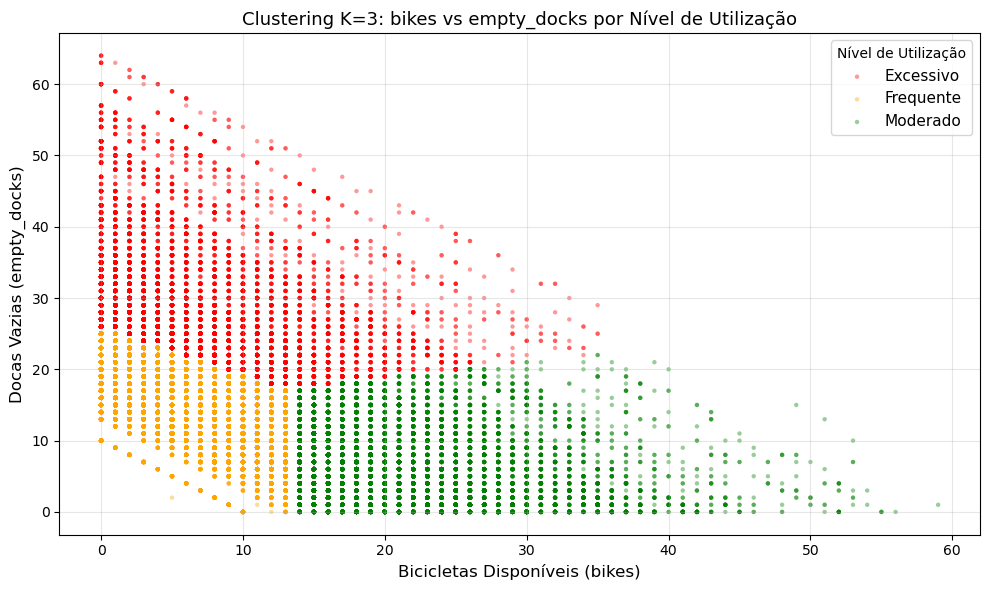

In [51]:
# Converter uma amostra para Pandas para visualização
pdf_scatter = (
    df_pred
    .select('bikes', 'empty_docks', 'docks', 'nivel_utilizacao')
    .sample(fraction=0.02, seed=42)
    .toPandas()
)

# Cores por nível de utilização (conforme o relatório)
cores = {'Excessivo': 'red', 'Moderado': 'green', 'Frequente': 'orange'}

fig, ax = plt.subplots(figsize=(10, 6))

for nivel, grupo in pdf_scatter.groupby('nivel_utilizacao'):
    ax.scatter(
        grupo['bikes'],
        grupo['empty_docks'],
        c=cores.get(nivel, 'gray'),
        label=nivel,
        alpha=0.4,
        s=10,
        edgecolors='none'
    )

ax.set_xlabel('Bicicletas Disponíveis (bikes)', fontsize=12)
ax.set_ylabel('Docas Vazias (empty_docks)', fontsize=12)
ax.set_title('Clustering K=3: bikes vs empty_docks por Nível de Utilização', fontsize=13)
ax.legend(title='Nível de Utilização', fontsize=11)
ax.grid(True, alpha=0.3)

os.makedirs('visualizations', exist_ok=True)
plt.tight_layout()
plt.savefig('visualizations/clusters_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

---
## **6. Guardar Resultados**

As observações classificadas são guardadas na collection `bikes_modelled_summer` do MongoDB. Cada documento inclui os campos originais mais `nivel_utilizacao` (o estado de utilização atribuído pelo modelo).

In [52]:
# Selecionar apenas as colunas relevantes (excluir vectores internos do Spark)
df_output = df_pred.select(
    'query_time', 'Date', 'Hour', 'Minute', 'place_id', 'common_name', 'lat', 'lon',
    'bikes', 'empty_docks', 'docks',
    F.col('prediction').alias('cluster_id'),
    'nivel_utilizacao'
)

# Escrever na collection bikes_modelled_summer
(
    df_output.write
        .format('mongodb')
        .mode('overwrite')
        .option('connection.uri', 'mongodb://mongodb:27017/')
        .option('database', 'london_bikes')
        .option('collection', 'bikes_modelled_summer')
        .save()
)

total = db['bikes_modelled_summer'].count_documents({})
print(f'Guardados {total:,} documentos em bikes_modelled_summer.')
print('\nExemplo de documento:')
pprint.pprint(db['bikes_modelled_summer'].find_one({}, {'_id': 0}))

Guardados 3,048,965 documentos em bikes_modelled_summer.

Exemplo de documento:
{'Date': datetime.datetime(2022, 7, 2, 0, 0),
 'Hour': 0,
 'Minute': 14,
 'bikes': 11,
 'cluster_id': 1,
 'common_name': 'Limerston Street, West Chelsea',
 'docks': 18,
 'empty_docks': 7,
 'lat': 51.485587,
 'lon': -0.18119,
 'nivel_utilizacao': 'Frequente',
 'place_id': 'BikePoints_573',
 'query_time': datetime.datetime(2022, 7, 2, 0, 14, 48, 384000)}


---
## **7. Visualização Geográfica**

Mapa interativo de Londres mostrando o nível de utilização de cada estação numa janela temporal específica.

**Janela temporal:** 31 de Julho de 2022, 14:30–15:00 (hora de pico da tarde).

**Cor dos marcadores:**
- 🔴 **Excessivo** — muita procura, poucas bicicletas disponíveis
- 🟢 **Moderado** — muitas bicicletas disponíveis, pouca procura
- 🟠 **Frequente** — estado de equilíbrio

In [53]:
# Filtrar observações para um instante temporal concreto (granularidade real)
data_filtro = '2022-07-31'
hora_filtro = 14
minuto_preferido = 45

df_modelled = (
    spark.read
        .format('mongodb')
        .option('connection.uri', 'mongodb://mongodb:27017/')
        .option('database', 'london_bikes')
        .option('collection', 'bikes_modelled_summer')
        .load()
)

df_hora = df_modelled.filter(
    (F.col('Date') == data_filtro) &
    (F.col('Hour') == hora_filtro)
)

minutos_disponiveis = [
    row['Minute'] for row in df_hora.select('Minute').distinct().orderBy('Minute').collect()
]
print(f'Minutos disponíveis para {data_filtro} as {hora_filtro:02d}h: {minutos_disponiveis}')

if not minutos_disponiveis:
    raise ValueError(f'Não existem observações para {data_filtro} às {hora_filtro:02d}h.')

minuto_filtro = minuto_preferido if minuto_preferido in minutos_disponiveis else min(minutos_disponiveis, key=lambda m: abs(m - minuto_preferido))
if minuto_filtro != minuto_preferido:
    print(f'Minuto {minuto_preferido:02d} indisponível; a usar o mais próximo: {minuto_filtro:02d}.')

df_janela = df_hora.filter(F.col('Minute') == minuto_filtro)
print(f'Observações no instante [{data_filtro} {hora_filtro:02d}:{minuto_filtro:02d}]: {df_janela.count():,}')

Minutos disponíveis para 2022-07-31 as 14h: [5, 23, 34, 49]
Minuto 45 indisponível; a usar o mais próximo: 49.
Observações no instante [2022-07-31 14:49]: 424


In [54]:
# Converter para Pandas
pdf_map = df_janela.select(
    'place_id', 'common_name', 'query_time', 'lat', 'lon', 'bikes', 'empty_docks', 'docks', 'nivel_utilizacao'
).toPandas()

if pdf_map.empty:
    raise ValueError('A selecao temporal resultou em zero registos; confirmar a data, hora e minuto escolhidos.')

print(f'Estações no mapa: {len(pdf_map)}')
print(pdf_map['nivel_utilizacao'].value_counts().to_string())

Estações no mapa: 424
nivel_utilizacao
Frequente    234
Excessivo     99
Moderado      91


In [55]:
# Cores por nível de utilização
cores_folium = {'Excessivo': 'red', 'Moderado': 'green', 'Frequente': 'orange'}

# Criar mapa centrado em Londres
mapa = folium.Map(location=[51.5074, -0.1278], zoom_start=12)

# Adicionar um pino por estação
for _, row in pdf_map.iterrows():
    cor = cores_folium.get(row['nivel_utilizacao'], 'gray')
    nome_estacao = row['common_name'] if isinstance(row['common_name'], str) and row['common_name'].strip() else row['place_id']
    popup_html = (
        '<b>{}</b><br>'
        'Place ID: {}<br>'
        'Nível de Utilização: <b>{}</b><br>'
        'Bicicletas: {}<br>'
        'Docas vazias: {}<br>'
        'Capacidade: {}'
    ).format(
        nome_estacao, row['place_id'], row['nivel_utilizacao'],
        int(row['bikes']), int(row['empty_docks']), int(row['docks'])
    )
    folium.Marker(
        location=[row['lat'], row['lon']],
        icon=folium.Icon(color=cor, icon='bicycle', prefix='fa'),
        tooltip=nome_estacao,
        popup=folium.Popup(popup_html, max_width=260)
    ).add_to(mapa)

# Legenda HTML
legenda_items = ''.join(
    '<span style="color:{c};font-size:18px;">&#9679;</span> {n}<br>'.format(c=cor, n=nome)
    for nome, cor in cores_folium.items()
)
legenda_html = (
    '<div style="position:fixed;bottom:30px;left:30px;background:white;'
    'padding:12px;border:1px solid #ccc;border-radius:6px;font-size:13px;z-index:1000;">'
    '<b>Nível de Utilização</b><br>'
    f'<small>{data_filtro} · {hora_filtro:02d}:{minuto_filtro:02d}</small><br><br>'
    + legenda_items +
    '</div>'
)
mapa.get_root().html.add_child(folium.Element(legenda_html))

os.makedirs('visualizations', exist_ok=True)
mapa.save('visualizations/mapa_nivel_utilizacao.html')
print('Mapa guardado → visualizations/mapa_nivel_utilizacao.html')
mapa

Mapa guardado → visualizations/mapa_nivel_utilizacao.html
